Implementation of MCP neuron

AND

In [1]:
def MCP_Neurons_AND(X1, X2, T):
    """
    This function implements basic AND operations with MCP Neuron for two inputs.
    """
    assert len(X1) == len(X2)

    state_neuron = []

    for i in range(len(X1)):
        total = X1[i] + X2[i]

        if total >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron

In [2]:
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 2

result = MCP_Neurons_AND(X1, X2, T)
print(result)

[0, 0, 0, 1]


OR

In [3]:
def MCP_Neurons_OR(X1, X2, T):
    """
    This function implements basic OR operations with MCP Neuron for two inputs.
    """
    assert len(X1) == len(X2)

    state_neuron = []

    for i in range(len(X1)):
        total = X1[i] + X2[i]

        if total >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron

In [4]:
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 1

result_or = MCP_Neurons_OR(X1, X2, T)
print(result_or)

[0, 1, 1, 1]


Question 1: Limitations of MCP neurons



The MCP neuron has several limitations. It is a highly simplified model of a biological neuron and does not accurately represent the complex behavior of real neurons. It only works with binary inputs and binary outputs, which makes it too limited for many real-world problems. The threshold value must usually be chosen manually, so the neuron does not learn automatically from data. Another major limitation is that a single MCP neuron can only solve linearly separable problems, such as AND and OR, but it cannot solve non-linearly separable problems like XOR. It also does not use trainable weights in its simplest form, making it less flexible than later models such as the perceptron. Because of these limitations, MCP neurons are mainly important as a historical foundation for the development of artificial neural networks rather than as practical modern learning models.

Question 2: Can MCP neuron solve XOR?

A single MCP neuron cannot solve the XOR function because XOR is not linearly separable. The MCP neuron works by summing the inputs and comparing the result with a single threshold value. For XOR, the output should be 1 when the input sum is 1, but 0 when the input sum is 0 or 2. No single threshold can satisfy these conditions at the same time. Therefore, XOR cannot be implemented using one basic MCP neuron with a simple if-else threshold rule. It would require multiple neurons arranged in layers.

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Implementation for 0 Vs. 1 Classification.


## Step 1: Load the Dataset


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Load the dataset
df_0_1 = pd.read_csv("/content/drive/MyDrive/Datasets/mnist_0_and_1 (1).csv")  # Add the correct file path if necessary

# Extract features and labels
X = df_0_1.drop(columns=["label"]).values  # 784 pixels
y = df_0_1["label"].values  # Labels (0 or 1)

# Check the shape of the features and labels
print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

Feature matrix shape: (12665, 784)
Label vector shape: (12665,)


### Viewing the Dataset.


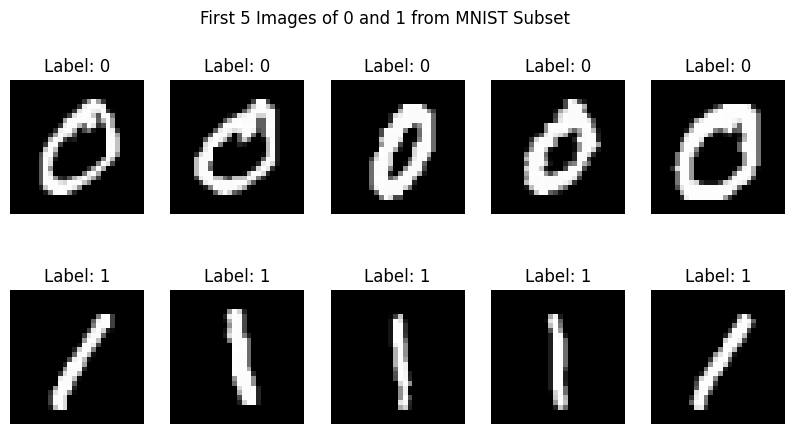

In [25]:
# Separate images for label 0 and label 1
images_0 = X[y == 0]  # Get all images with label 0
images_1 = X[y == 1]  # Get all images with label 1

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

# Check if the arrays have the required amount of data
if len(images_0) < 5 or len(images_1) < 5:
    print("Error: Not enough images in images_0 or images_1 to plot 5 images.")
else:
    for i in range(5):
        # Plot digit 0
        axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 0")
        axes[0, i].axis("off")
        # Plot digit 1
        axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 1")
        axes[1, i].axis("off")
    plt.suptitle("First 5 Images of 0 and 1 from MNIST Subset")
    plt.show()

## Step - 2 - Initializing the Weights:


In [26]:
# Initialize weights and bias
weights = np.zeros(X.shape[1])  # 784 weights (one for each pixel)
bias = 0
learning_rate = 0.1
epochs = 100

## Step - 3 - Make a Decision function:


In [ ]:
import numpy as np

def decision_function(X, weights, bias):
    """
    Compute the predicted labels for the input data.

    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - weights: Updated weights after training
    - bias: Updated bias after training

    Returns:
    - y_pred_all: The predicted labels for the input data
    """
    predictions = np.dot(X, weights) + bias
    #####Your Code Here############  # Activation function (step function)
    y_pred_all = np.where(predictions >= 0, 1, 0)
    return y_pred_all

## Step - 3 - Implement the Perceptron Learning Algorithm


In [ ]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Train the perceptron using the Perceptron Learning Algorithm.

    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - y: Labels (true output) as a numpy array of shape (n_samples,)
    - weights: Initial weights as a numpy array of shape (n_features,)
    - bias: Initial bias value (scalar)
    - learning_rate: Learning rate for weight updates (default is 0.1)
    - epochs: Number of iterations to train the model (default is 100)

    Returns:
    - weights: Updated weights after training
    - bias: Updated bias after training
    - accuracy: Total correct prediction.
    """
    # Step 3: Perceptron Learning Algorithm
    # Your Code here#
    for epoch in range(epochs):
        # For each epoch, we iterate through all data points
        for i in range(len(X)):
            # Calculate the predicted output (y_pred)
            # The perceptron's activation function is a step function (0 or 1)
            prediction = np.dot(X[i], weights) + bias
            y_pred = np.where(prediction >= 0, 1, 0)

            # Update weights and bias
            # The update rule is: weight = weight + learning_rate * (true_output - predicted_output) * input
            #                       bias = bias + learning_rate * (true_output - predicted_output)
            weights += learning_rate * (y[i] - y_pred) * X[i]
            bias += learning_rate * (y[i] - y_pred)

        # Calculate accuracy after each epoch
        final_predictions = np.dot(X, weights) + bias
        epoch_y_pred = np.where(final_predictions >= 0, 1, 0)
        accuracy = np.mean(epoch_y_pred == y)

        # Print accuracy every 10 epochs
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch + 1}: Accuracy = {accuracy:.4f}")


    return weights, bias, accuracy

## Training the Perceptron


In [27]:
# After training the model with the perceptron_learning_algorithm
weights, bias, accuracy = train_perceptron(X, y, weights, bias)

# Evaluate the model using the new function
print("The Final Accuracy is: ", accuracy)

The Final Accuracy is:  1.0


## Step 5: Visualize Misclassified Images

In [28]:
# Get predictions for all data points
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)

# Calculate final accuracy
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")

# Step 5: Visualize Misclassified Images
misclassified_idx = np.where(y_pred != y)[0]
if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx[:10]):  # Show 10 misclassified images

        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")
    plt.suptitle("Misclassified Images")
    plt.show()
else:
    print("All images were correctly classified!")

Final Accuracy: 1.0000
All images were correctly classified!


# **Task 3: Perceptron Algorithm for 3 vs 5 Classification.**
# Step 1: Load the Dataset


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Load the dataset
df_0_1 = pd.read_csv("/content/drive/MyDrive/Datasets/mnist_3_and_5 (1).csv")  # Add the correct file path if necessary

# Extract features and labels
X = df_0_1.drop(columns=["label"]).values  # 784 pixels
y = df_0_1["label"].values  # Labels (0 or 1)

# Check the shape of the features and labels
print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

Feature matrix shape: (2741, 784)
Label vector shape: (2741,)


# Viewing the Dataset.


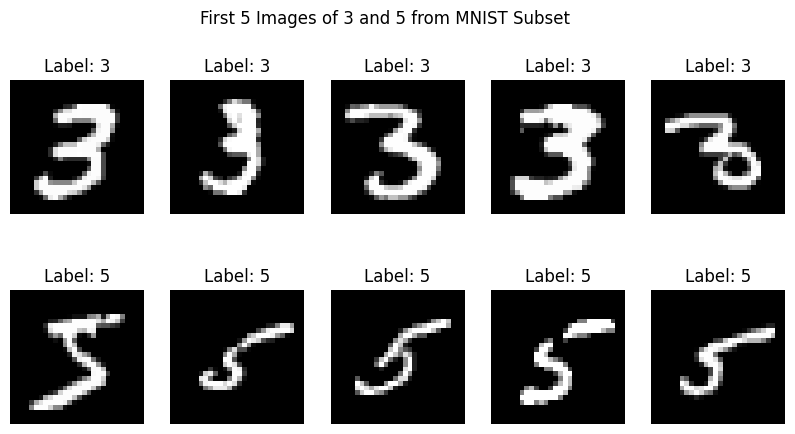

In [30]:
# Separate images for label 3 and label 5
images_3 = X[y == 3]
images_5 = X[y == 5]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

# Check if the arrays have the required amount of data
if len(images_3) < 5 or len(images_5) < 5:
    print(f"Error: Not enough images (Found {len(images_3)} of '3' and {len(images_5)} of '5') to plot.")
else:
    for i in range(5):
        # Plot digit 3
        axes[0, i].imshow(images_3[i].reshape(28, 28), cmap='gray')
        axes[0, i].set_title('Label: 3')
        axes[0, i].axis('off')
        # Plot digit 5
        axes[1, i].imshow(images_5[i].reshape(28, 28), cmap='gray')
        axes[1, i].set_title('Label: 5')
        axes[1, i].axis('off')
    plt.suptitle('First 5 Images of 3 and 5 from MNIST Subset')
    plt.show()

# Step - 2 - Initializing the Weights:


In [31]:
# Initialize weights and bias
weights = np.zeros(X.shape[1])  # 784 weights (one for each pixel)
bias = 0
learning_rate = 0.1
epochs = 100

# Step - 3 - Make a Decision function:

In [32]:
import numpy as np

def decision_function(X, weights, bias):
    """
    Compute the predicted labels for the input data.

    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - weights: Updated weights after training
    - bias: Updated bias after training

    Returns:
    - y_pred_all: The predicted labels for the input data
    """
    predictions = np.dot(X, weights) + bias
    #####Your Code Here############  # Activation function (step function)
    y_pred_all = np.where(predictions >= 0, 1, 0)
    return y_pred_all

# Step - 3 - Implement the Perceptron Learning Algorithm


In [33]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Train the perceptron using the Perceptron Learning Algorithm.

    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - y: Labels (true output) as a numpy array of shape (n_samples,)
    - weights: Initial weights as a numpy array of shape (n_features,)
    - bias: Initial bias value (scalar)
    - learning_rate: Learning rate for weight updates (default is 0.1)
    - epochs: Number of iterations to train the model (default is 100)

    Returns:
    - weights: Updated weights after training
    - bias: Updated bias after training
    - accuracy: Total correct prediction.
    """
    # Step 3: Perceptron Learning Algorithm
    # Your Code here#
    for epoch in range(epochs):
        # For each epoch, we iterate through all data points
        for i in range(len(X)):
            # Calculate the predicted output (y_pred)
            # The perceptron's activation function is a step function (0 or 1)
            prediction = np.dot(X[i], weights) + bias
            y_pred = np.where(prediction >= 0, 1, 0)

            # Update weights and bias
            # The update rule is: weight = weight + learning_rate * (true_output - predicted_output) * input
            #                       bias = bias + learning_rate * (true_output - predicted_output)
            weights += learning_rate * (y[i] - y_pred) * X[i]
            bias += learning_rate * (y[i] - y_pred)

        # Calculate accuracy after each epoch
        final_predictions = np.dot(X, weights) + bias
        epoch_y_pred = np.where(final_predictions >= 0, 1, 0)
        accuracy = np.mean(epoch_y_pred == y)

        # Print accuracy every 10 epochs
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch + 1}: Accuracy = {accuracy:.4f}")


    return weights, bias, accuracy

# Training the Perceptron


In [34]:
# After training the model with the perceptron_learning_algorithm
weights, bias, accuracy = train_perceptron(X, y, weights, bias)

# Evaluate the model using the new function
print("The Final Accuracy is: ", accuracy)

Epoch 10: Accuracy = 0.0000
Epoch 20: Accuracy = 0.0000
Epoch 30: Accuracy = 0.0000
Epoch 40: Accuracy = 0.0000
Epoch 50: Accuracy = 0.0000
Epoch 60: Accuracy = 0.0000
Epoch 70: Accuracy = 0.0000
Epoch 80: Accuracy = 0.0000
Epoch 90: Accuracy = 0.0000
Epoch 100: Accuracy = 0.0000
The Final Accuracy is:  0.0


# Step 5: Visualize Misclassified Images


Final Accuracy: 0.0000


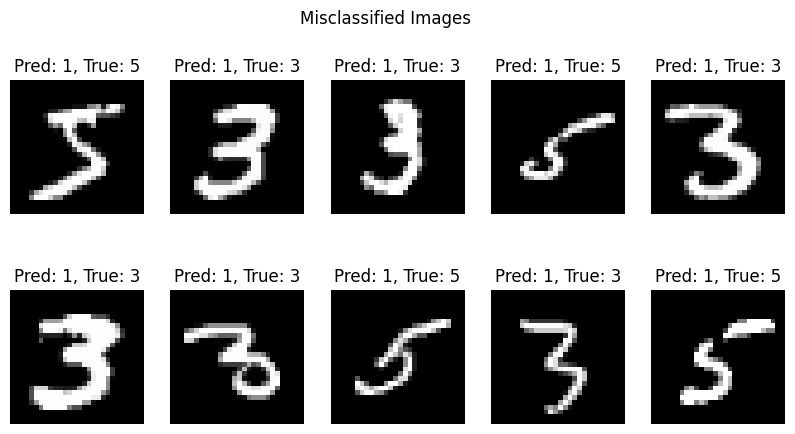

In [35]:
# Get predictions for all data points
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)

# Calculate final accuracy
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")

# Step 5: Visualize Misclassified Images
misclassified_idx = np.where(y_pred != y)[0]
if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx[:10]):  # Show 10 misclassified images

        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")
    plt.suptitle("Misclassified Images")
    plt.show()
else:
    print("All images were correctly classified!")

Question 8:
What does misclassified_idx store?

misclassified_idx stores the indices of all data samples where the predicted labels do not match the true labels. It is obtained by comparing the predicted output with the actual labels and identifying the positions where they are different. These indices are then used to retrieve and visualize the misclassified images from the dataset, allowing us to analyze where the model made mistakes.

What does it mean if:

“All images were correctly classified!”



If the output shows “All images were correctly classified!”, it means that the perceptron model achieved 100% accuracy on the dataset, correctly predicting every sample. This indicates that the data is likely linearly separable or simple enough for the perceptron to learn an accurate decision boundary. However, in real-world scenarios, especially for more complex datasets like handwritten digits, perfect classification is uncommon and may also indicate that the dataset is relatively small or less complex.